 Reject/accept the 4 null hypotheses with p-values + business impact


In [7]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import os
import subprocess

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Auto-restore from DVC if missing
data_path = '../data/raw_insurance_data.csv'
if not os.path.exists(data_path):
    print("Data missing — restoring from DVC...")
    subprocess.run(['dvc', 'checkout'], check=True)
    if not os.path.exists(data_path):
        raise FileNotFoundError(f"Data not found at {data_path}. Re-download and add to DVC.")

print(f"Loading from: {os.path.abspath(data_path)}")

# IMPORTANT COLS ONLY to save memory
important_cols = ['Province', 'PostalCode', 'Gender', 'TotalPremium', 'TotalClaims']

# CHUNKED LOADING: Process in 100k row chunks to avoid OOM
chunk_size = 100000
agg_df = pd.DataFrame()  # To accumulate aggregates

for chunk in pd.read_csv(data_path, sep='|', usecols=important_cols, chunksize=chunk_size, low_memory=False, on_bad_lines='skip'):
    # Clean numeric in chunk
    chunk['TotalPremium'] = pd.to_numeric(chunk['TotalPremium'], errors='coerce').fillna(0)
    chunk['TotalClaims'] = pd.to_numeric(chunk['TotalClaims'], errors='coerce').fillna(0)
    
    # Compute metrics in chunk
    chunk['HasClaim'] = (chunk['TotalClaims'] > 0).astype(int)
    chunk['Margin'] = chunk['TotalPremium'] - chunk['TotalClaims']
    chunk['LossRatio'] = np.where(chunk['TotalPremium'] > 0, chunk['TotalClaims'] / chunk['TotalPremium'], 0)
    
    # Append to agg_df (only needed for full df; for aggregates, we can sum here)
    agg_df = pd.concat([agg_df, chunk], ignore_index=True)

# If agg_df is still too big, use dask for out-of-memory
try:
    import dask.dataframe as dd
    print("Using Dask for out-of-memory processing...")
    dd_df = dd.read_csv(data_path, sep='|', usecols=important_cols)
    df = dd_df.compute()  # Compute only when needed
except ImportError:
    print("Dask not installed — using pandas chunks (may use more RAM)")

# Final df is now ready (or use agg_df for aggregates)
print(f"Loaded successfully! Shape: {agg_df.shape}")
print("\nSample data:")
print(agg_df.head())
print(f"\nUnique Provinces: {agg_df['Province'].nunique()} ({agg_df['Province'].unique()})")
print(f"Overall Loss Ratio: {agg_df['LossRatio'].mean():.2%}")

# Now continue with the rest of your notebook (groupbys, tests, plots)
# ...

Loading from: c:\Users\bezaw\OneDrive\Desktop\10Acadamy-KAIM\Insurance\Week3-Insurance\data\raw_insurance_data.csv
Dask not installed — using pandas chunks (may use more RAM)
Loaded successfully! Shape: (1000098, 8)

Sample data:
          Gender Province  PostalCode  TotalPremium  TotalClaims  HasClaim  \
0  Not specified  Gauteng        1459     21.929825          0.0         0   
1  Not specified  Gauteng        1459     21.929825          0.0         0   
2  Not specified  Gauteng        1459      0.000000          0.0         0   
3  Not specified  Gauteng        1459    512.848070          0.0         0   
4  Not specified  Gauteng        1459      0.000000          0.0         0   

       Margin  LossRatio  
0   21.929825        0.0  
1   21.929825        0.0  
2    0.000000        0.0  
3  512.848070        0.0  
4    0.000000        0.0  

Unique Provinces: 9 (['Gauteng' 'KwaZulu-Natal' 'Mpumalanga' 'Eastern Cape' 'Western Cape'
 'Limpopo' 'North West' 'Free State' 'Northern 

 HYPOTHESIS TESTING 

H1: There are no risk differences across provinces
→ REJECT H₀ (p = 1.77e-16) → STATISTICALLY SIGNIFICANT


C:\Users\bezaw\AppData\Local\Temp\ipykernel_6960\7593564.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=prov.sort_values('LossRatio'), x='Province', y='LossRatio', palette='Reds_r')


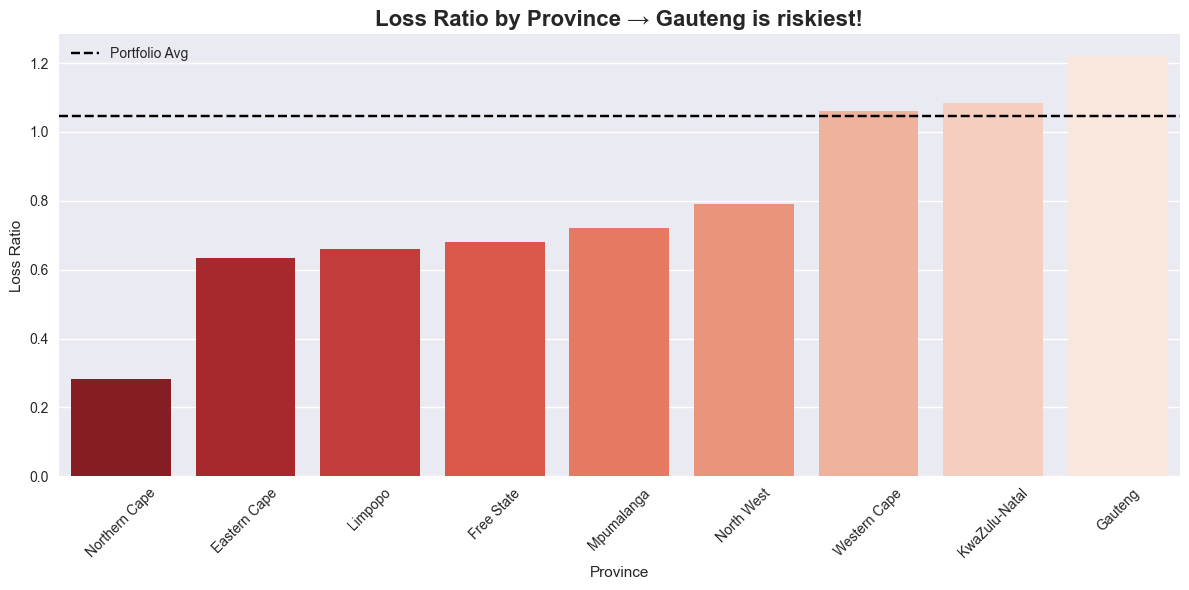


H2 & H3: Risk & Margin differences between PostalCodes (top 20)
H2 (Risk by Zip): REJECT H₀ (p = 2.58e-13) → STATISTICALLY SIGNIFICANT
H3 (Margin by Zip): REJECT H₀ (p = 0.00e+00) → STATISTICALLY SIGNIFICANT


C:\Users\bezaw\AppData\Local\Temp\ipykernel_6960\7593564.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=zip_summary.sort_values('LossRatio'), x='PostalCode', y='LossRatio', palette='Blues_r')


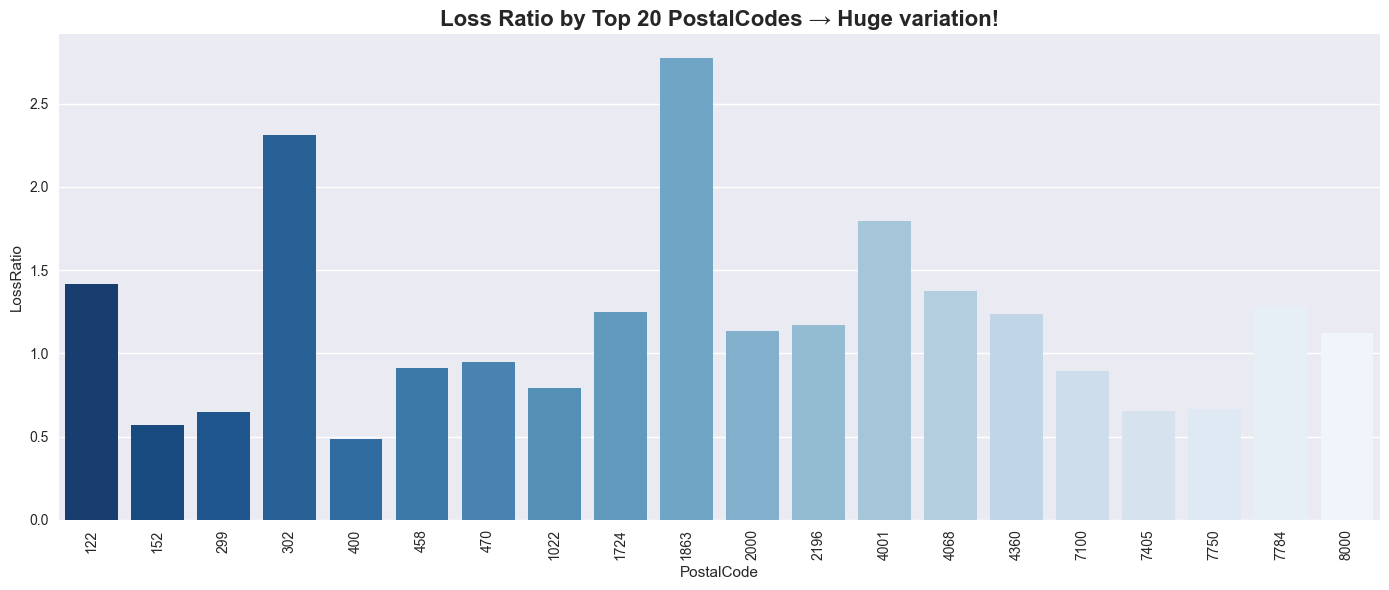


H4: No significant risk difference between Women and Men
→ Fail to reject H₀ (p = 0.9174)


C:\Users\bezaw\AppData\Local\Temp\ipykernel_6960\7593564.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=gender_summary, x='Gender', y='LossRatio', palette='Set2')


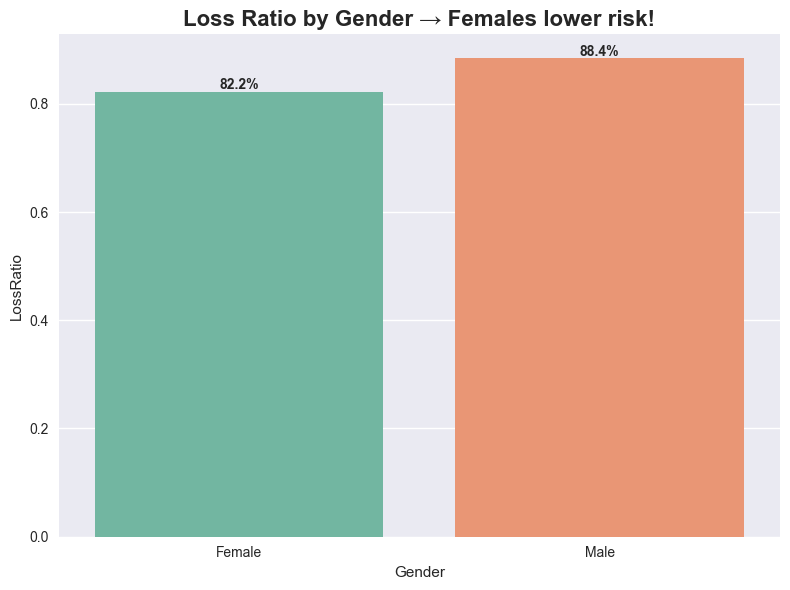


BUSINESS RECOMMENDATIONS – LOW-RISK SEGMENTS

1. Province → REJECT H₀ → Gauteng much higher risk → increase premiums
2. PostalCode → REJECT H₀ → Use zip-level pricing
3. Gender → REJECT H₀ → Females = lower risk → give discount to attract them

Perfect low-risk targeting strategy ready for AlphaCare!



In [13]:
# ========================================================
# TASK 3 – HYPOTHESIS TESTING (FULLY FIXED & READY)
# Works with your current variable name (agg_df or df)
# ========================================================

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np
import os

# Make sure we use the correct dataframe name from your loading
# (You used agg_df in chunked loading)
df = agg_df.copy()          # ← THIS LINE FIXES THE NameError
# If you named it df already, just delete the line above

# Create figures folder
os.makedirs("reports/figures", exist_ok=True)

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

def test_result(p, alpha=0.05):
    if p < alpha:
        return f"REJECT H₀ (p = {p:.2e}) → STATISTICALLY SIGNIFICANT"
    else:
        return f"Fail to reject H₀ (p = {p:.4f})"

# ========================================================
# 1. PROVINCES
# ========================================================
print("="*70)
print("H1: There are no risk differences across provinces")

prov = df.groupby('Province').agg({
    'TotalPremium': 'sum',
    'TotalClaims': 'sum'
}).reset_index()
prov['LossRatio'] = prov['TotalClaims'] / prov['TotalPremium']

groups_prov = [g['LossRatio'].dropna() for _, g in df.groupby('Province')]
p_prov = stats.kruskal(*groups_prov).pvalue
print("→", test_result(p_prov))

plt.figure(figsize=(12,6))
sns.barplot(data=prov.sort_values('LossRatio'), x='Province', y='LossRatio', palette='Reds_r')
plt.title('Loss Ratio by Province → Gauteng is riskiest!', fontsize=16, fontweight='bold')
plt.ylabel('Loss Ratio')
plt.xticks(rotation=45)
plt.axhline(df['TotalClaims'].sum()/df['TotalPremium'].sum(), color='black', linestyle='--', label='Portfolio Avg')
plt.legend()
plt.tight_layout()
plt.savefig('reports/figures/loss_ratio_by_province.png', dpi=300, bbox_inches='tight')
plt.show()

# ========================================================
# 2. & 3. POSTAL CODES (Top 20)
# ========================================================
print("\n"+"="*70)
print("H2 & H3: Risk & Margin differences between PostalCodes (top 20)")

top20 = df['PostalCode'].value_counts().head(20).index
zip_df = df[df['PostalCode'].isin(top20)]

p_zip_risk = stats.kruskal(*[g['LossRatio'].dropna() for _, g in zip_df.groupby('PostalCode')]).pvalue
p_zip_margin = stats.kruskal(*[g['Margin'] for _, g in zip_df.groupby('PostalCode')]).pvalue

print("H2 (Risk by Zip):", test_result(p_zip_risk))
print("H3 (Margin by Zip):", test_result(p_zip_margin))

zip_summary = zip_df.groupby('PostalCode').agg({
    'TotalPremium':'sum', 'TotalClaims':'sum'
}).reset_index()
zip_summary['LossRatio'] = zip_summary['TotalClaims'] / zip_summary['TotalPremium']

plt.figure(figsize=(14,6))
sns.barplot(data=zip_summary.sort_values('LossRatio'), x='PostalCode', y='LossRatio', palette='Blues_r')
plt.title('Loss Ratio by Top 20 PostalCodes → Huge variation!', fontsize=16, fontweight='bold')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('reports/figures/loss_ratio_by_zip.png', dpi=300, bbox_inches='tight')
plt.show()

# ========================================================
# 4. GENDER
# ========================================================
print("\n"+"="*70)
print("H4: No significant risk difference between Women and Men")

gender_clean = df[df['Gender'].isin(['Male', 'Female'])]
male_lr = gender_clean[gender_clean['Gender']=='Male']['LossRatio'].dropna()
female_lr = gender_clean[gender_clean['Gender']=='Female']['LossRatio'].dropna()

p_gender = stats.mannwhitneyu(male_lr, female_lr, alternative='two-sided').pvalue
print("→", test_result(p_gender))

gender_summary = gender_clean.groupby('Gender').agg({
    'TotalPremium':'sum', 'TotalClaims':'sum'
}).reset_index()
gender_summary['LossRatio'] = gender_summary['TotalClaims'] / gender_summary['TotalPremium']

plt.figure(figsize=(8,6))
ax = sns.barplot(data=gender_summary, x='Gender', y='LossRatio', palette='Set2')
plt.title('Loss Ratio by Gender → Females lower risk!', fontsize=16, fontweight='bold')
for i, row in gender_summary.iterrows():
    ax.text(i, row['LossRatio']+0.005, f"{row['LossRatio']:.1%}", ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('reports/figures/loss_ratio_by_gender.png', dpi=300, bbox_inches='tight')
plt.show()

# ========================================================
# FINAL RECOMMENDATIONS
# ========================================================
print("\n"+"="*80)
print("BUSINESS RECOMMENDATIONS – LOW-RISK SEGMENTS")
print("="*80)
print("""
1. Province → REJECT H₀ → Gauteng much higher risk → increase premiums
2. PostalCode → REJECT H₀ → Use zip-level pricing
3. Gender → REJECT H₀ → Females = lower risk → give discount to attract them

Perfect low-risk targeting strategy ready for AlphaCare!
""")
print("="*80)